In [1]:
import os
import json
import sys
from google.colab import drive

# 1. Mount Drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted.")

# 2. CheXpert-Pneumonia split file check (won't exist yet)
split_path = '/content/drive/MyDrive/MediScan_AI/training/datasets/pneumonia_chexpert/split.json'
print("CheXpert-Pneumonia split file present:", os.path.exists(split_path))

# 3. Kaggle token check
if not os.path.exists('/root/.kaggle/access_token'):
    print("Kaggle token missing — paste your token below and re-run this cell.")
    token = ""  # paste token here
    if token:
        os.makedirs('/root/.kaggle', exist_ok=True)
        with open('/root/.kaggle/access_token', 'w') as f:
            f.write(token)
        os.chmod('/root/.kaggle/access_token', 0o600)
        print("Kaggle token written.")
else:
    print("Kaggle token already present.")

# 4. Repo clone/pull (same Drive clone used for Pneumonia & Cardiomegaly)
repo_dir = '/content/drive/MyDrive/MediScan_AI/repo'
if not os.path.exists(repo_dir):
    print("Cloning repo to Drive (first time only)...")
    !git clone https://github.com/zimcodes1/MEDISCAN.git {repo_dir}
else:
    print("Repo already cloned on Drive.")

%cd {repo_dir}
!git checkout training/model-development
!git pull

if repo_dir not in sys.path:
    sys.path.append(repo_dir)
print("Repo ready at:", repo_dir)

# 5. Load split if it exists
if os.path.exists(split_path):
    with open(split_path) as f:
        split_data = json.load(f)
    train_files = split_data['train']
    val_files = split_data['val']
    test_files = split_data['test']
    print(f"Split loaded — train: {len(train_files)}, val: {len(val_files)}, test: {len(test_files)}")
else:
    print("→ No split.json yet — proceed to dataset acquisition.")

# 6. Device check
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Mounted at /content/drive
CheXpert-Pneumonia split file present: False
Kaggle token missing — paste your token below and re-run this cell.
Repo already cloned on Drive.
/content/drive/MyDrive/MediScan_AI/repo
Already on 'training/model-development'
Your branch is up to date with 'origin/training/model-development'.
remote: Enumerating objects: 89, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 57 (delta 21), reused 50 (delta 14), pack-reused 0 (from 0)
Unpacking objects: 100% (57/57), 14.77 MiB | 3.14 MiB/s, done.
From https://github.com/zimcodes1/MEDISCAN
   0728f73..1191c74  training/model-development -> origin/training/model-development
 * [new branch]      azimeh_branch -> origin/azimeh_branch
Updating 0728f73..1191c74
Fast-forward
 model_training/PROJECT_LOG.md                      |  523 ++--
 model_training/cardiomegaly_guide.md               |  344 +++
 model_training/configs/pneumonia.yaml              |    3 

In [2]:
!kaggle datasets download -d ashery/chexpert -p /content/
!unzip -q /content/chexpert.zip -d /content/chexpert_data/

import os
for item in os.listdir('/content/chexpert_data'):
    print(item)

Dataset URL: https://www.kaggle.com/datasets/ashery/chexpert
License(s): CC0-1.0
100% 10.7G/10.7G [02:29<00:00, 77.1MB/s]

valid.csv
train.csv
train
valid


In [4]:
import pandas as pd

train_csv_path = '/content/chexpert_data/train.csv'
train_df = pd.read_csv(train_csv_path)

print(train_df.shape)
print(train_df.columns.tolist())
print(train_df['Pneumonia'].value_counts(dropna=False))

(223414, 19)
['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']
Pneumonia
 NaN    195806
-1.0     18770
 1.0      6039
 0.0      2799
Name: count, dtype: int64


In [5]:
print(train_df['No Finding'].value_counts(dropna=False))


No Finding
NaN    201033
1.0     22381
Name: count, dtype: int64


In [6]:
pneumonia_positive = train_df[train_df['Pneumonia'] == 1.0].copy()
no_finding_negative = train_df[train_df['No Finding'] == 1.0].copy()

print(f"Pneumonia positive: {len(pneumonia_positive)}")
print(f"No Finding negative pool available: {len(no_finding_negative)}")

import random
random.seed(42)

n_positive = len(pneumonia_positive)
n_negative_target = n_positive * 3

negative_sample = no_finding_negative.sample(n=min(n_negative_target, len(no_finding_negative)), random_state=42)

print(f"Negative (sampled): {len(negative_sample)}")
print(f"Ratio (neg:pos): {len(negative_sample)/n_positive:.3f}")

Pneumonia positive: 6039
No Finding negative pool available: 22381
Negative (sampled): 18117
Ratio (neg:pos): 3.000


In [7]:
print(train_df['Path'].head(10).tolist())


['CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg', 'CheXpert-v1.0-small/train/patient00002/study2/view1_frontal.jpg', 'CheXpert-v1.0-small/train/patient00002/study1/view1_frontal.jpg', 'CheXpert-v1.0-small/train/patient00002/study1/view2_lateral.jpg', 'CheXpert-v1.0-small/train/patient00003/study1/view1_frontal.jpg', 'CheXpert-v1.0-small/train/patient00004/study1/view1_frontal.jpg', 'CheXpert-v1.0-small/train/patient00004/study1/view2_lateral.jpg', 'CheXpert-v1.0-small/train/patient00005/study1/view1_frontal.jpg', 'CheXpert-v1.0-small/train/patient00005/study1/view2_lateral.jpg', 'CheXpert-v1.0-small/train/patient00005/study2/view1_frontal.jpg']


In [8]:
import re

def extract_patient_id(path):
    match = re.search(r'patient(\d+)', path)
    return match.group(1) if match else None

def fix_path(path):
    # strip the CheXpert-v1.0-small/ prefix, point at actual extracted location
    relative = path.replace('CheXpert-v1.0-small/', '')
    return f'/content/chexpert_data/{relative}'

# Combine positive + negative, filter to frontal only
combined = pd.concat([pneumonia_positive, negative_sample])
combined = combined[combined['Frontal/Lateral'] == 'Frontal'].copy()

combined['patient_id'] = combined['Path'].apply(extract_patient_id)
combined['full_path'] = combined['Path'].apply(fix_path)
combined['label'] = (combined['Pneumonia'] == 1.0).astype(int)

print(f"Total after frontal-only filter: {len(combined)}")
print(combined['label'].value_counts())
print(f"Unique patients: {combined['patient_id'].nunique()}")

Total after frontal-only filter: 18396
label
0    13721
1     4675
Name: count, dtype: int64
Unique patients: 15131


In [9]:
from sklearn.model_selection import GroupShuffleSplit

# First split: 80% train, 20% temp — grouped by patient_id
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, temp_idx = next(gss1.split(combined, groups=combined['patient_id']))

train_df_split = combined.iloc[train_idx]
temp_df_split = combined.iloc[temp_idx]

# Second split: temp (20%) -> 10% val, 10% test — grouped by patient_id again
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df_split, groups=temp_df_split['patient_id']))

val_df_split = temp_df_split.iloc[val_idx]
test_df_split = temp_df_split.iloc[test_idx]

print(f"Train: {len(train_df_split)} images, {train_df_split['patient_id'].nunique()} patients")
print(f"Val:   {len(val_df_split)} images, {val_df_split['patient_id'].nunique()} patients")
print(f"Test:  {len(test_df_split)} images, {test_df_split['patient_id'].nunique()} patients")

# Confirm no patient overlap across splits
train_patients = set(train_df_split['patient_id'])
val_patients = set(val_df_split['patient_id'])
test_patients = set(test_df_split['patient_id'])

print(f"\nTrain/Val overlap: {len(train_patients & val_patients)}")
print(f"Train/Test overlap: {len(train_patients & test_patients)}")
print(f"Val/Test overlap: {len(val_patients & test_patients)}")

# Class balance per split
print(f"\nTrain labels: {train_df_split['label'].value_counts().to_dict()}")
print(f"Val labels:   {val_df_split['label'].value_counts().to_dict()}")
print(f"Test labels:  {test_df_split['label'].value_counts().to_dict()}")

Train: 14740 images, 12104 patients
Val:   1840 images, 1513 patients
Test:  1816 images, 1514 patients

Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0

Train labels: {0: 10944, 1: 3796}
Val labels:   {0: 1384, 1: 456}
Test labels:  {0: 1393, 1: 423}


In [10]:
import os
import json

save_dir = '/content/drive/MyDrive/MediScan_AI/training/datasets/pneumonia_chexpert'
os.makedirs(save_dir, exist_ok=True)

def df_to_pairs(df):
    return list(zip(df['full_path'].tolist(), df['label'].tolist()))

split_data = {
    'train': df_to_pairs(train_df_split),
    'val': df_to_pairs(val_df_split),
    'test': df_to_pairs(test_df_split),
}

with open(os.path.join(save_dir, 'split.json'), 'w') as f:
    json.dump(split_data, f, indent=2)

print("Saved CheXpert-Pneumonia split to Drive.")
print(f"Path: {os.path.join(save_dir, 'split.json')}")

Saved CheXpert-Pneumonia split to Drive.
Path: /content/drive/MyDrive/MediScan_AI/training/datasets/pneumonia_chexpert/split.json


In [11]:
train_labels = [label for _, label in split_data['train']]
pos_weight = train_labels.count(0) / train_labels.count(1)
print(f"pos_weight: {pos_weight:.4f}")

pos_weight: 2.8830


In [12]:
%cd {repo_dir}
!git pull

import importlib
import model_training.preprocessing.preprocess as preprocess_module
importlib.reload(preprocess_module)
from model_training.preprocessing.preprocess import preprocess, load_and_convert, resize, crop_thorax

import inspect
print(inspect.getsource(preprocess))

/content/drive/MyDrive/MediScan_AI/repo
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 10 (delta 5), reused 8 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 2.36 KiB | 3.00 KiB/s, done.
From https://github.com/zimcodes1/MEDISCAN
   1191c74..04bf1b6  training/model-development -> origin/training/model-development
Updating 1191c74..04bf1b6
Fast-forward
 model_training/configs/pneumonia_chexpert.yaml | 70 ++++++++++++++++++++++++++
 model_training/preprocessing/preprocess.py     | 10 +++-
 2 files changed, 78 insertions(+), 2 deletions(-)
 create mode 100644 model_training/configs/pneumonia_chexpert.yaml
def preprocess(image_path, train=False, apply_crop=True):
    """Full pipeline. Returns array of shape (1, 3, 224, 224).

    Set train=True to apply augmentation (training only — never
    at inference time).
    Set apply_crop=False to skip the thorax crop step — used w

In [13]:
from torch.utils.data import Dataset

class XrayDatasetChexpert(Dataset):
    def __init__(self, pairs, train=False):
        self.pairs = pairs  # list of (filepath, label) tuples
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        filepath, label = self.pairs[idx]
        arr = preprocess(filepath, train=self.train, apply_crop=False)
        arr = arr.squeeze(0)
        return torch.from_numpy(arr), torch.tensor([label], dtype=torch.float32)

In [14]:
from torch.utils.data import Dataset, DataLoader

class XrayDatasetChexpert(Dataset):
    def __init__(self, pairs, train=False):
        self.pairs = pairs
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        filepath, label = self.pairs[idx]
        arr = preprocess(filepath, train=self.train, apply_crop=False)
        arr = arr.squeeze(0)
        return torch.from_numpy(arr), torch.tensor([label], dtype=torch.float32)


train_dataset = XrayDatasetChexpert(split_data['train'], train=True)
val_dataset = XrayDatasetChexpert(split_data['val'], train=False)
test_dataset = XrayDatasetChexpert(split_data['test'], train=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# sanity check one batch
batch_x, batch_y = next(iter(train_loader))
print(batch_x.shape, batch_y.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32, 1])


In [15]:
import torch
import torch.nn as nn
from torchvision import models

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(in_features=1280, out_features=1)
model = model.to(device)

pos_weight_value = 2.8830
pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

checkpoint_dir = '/content/drive/MyDrive/MediScan_AI/training/models/pneumonia_chexpert'
os.makedirs(checkpoint_dir, exist_ok=True)

print("Fresh model ready. Checkpoint dir:", checkpoint_dir)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 160MB/s]


Fresh model ready. Checkpoint dir: /content/drive/MyDrive/MediScan_AI/training/models/pneumonia_chexpert


In [16]:
from sklearn.metrics import roc_auc_score

def run_epoch(loader, train_mode, optimizer=None):
    if train_mode and optimizer is None:
        raise ValueError("optimizer must be provided when train_mode=True")

    model.train() if train_mode else model.eval()
    total_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.set_grad_enabled(train_mode):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            if train_mode:
                optimizer.zero_grad()

            logits = model(x)
            loss = criterion(logits, y)

            if train_mode:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_probs.extend(probs.flatten().tolist())
            all_labels.extend(y.cpu().numpy().flatten().tolist())

    avg_loss = total_loss / len(loader.dataset)
    auc = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc

print("run_epoch defined.")

run_epoch defined.


stage 1 training

In [17]:
for name, param in model.named_parameters():
    param.requires_grad = name.startswith('classifier')

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

best_val_loss = float('inf')

for epoch in range(5):
    train_loss, train_auc = run_epoch(train_loader, train_mode=True, optimizer=optimizer)
    val_loss, val_auc = run_epoch(val_loader, train_mode=False)

    print(f"Epoch {epoch+1}/5 | train_loss={train_loss:.4f} train_auc={train_auc:.4f} "
          f"| val_loss={val_loss:.4f} val_auc={val_auc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'stage1_best.pth'))
        print(f"  → New best checkpoint saved (val_loss={val_loss:.4f})")

Epoch 1/5 | train_loss=0.8658 train_auc=0.7666 | val_loss=0.7841 val_auc=0.8091
  → New best checkpoint saved (val_loss=0.7841)
Epoch 2/5 | train_loss=0.8194 train_auc=0.7951 | val_loss=0.7851 val_auc=0.8111
Epoch 3/5 | train_loss=0.8039 train_auc=0.8036 | val_loss=0.7757 val_auc=0.8134
  → New best checkpoint saved (val_loss=0.7757)
Epoch 4/5 | train_loss=0.8117 train_auc=0.7994 | val_loss=0.7619 val_auc=0.8215
  → New best checkpoint saved (val_loss=0.7619)
Epoch 5/5 | train_loss=0.8063 train_auc=0.8020 | val_loss=0.7665 val_auc=0.8204


stage 2 training

In [18]:
for name, param in model.named_parameters():
    if name.startswith('features.7') or name.startswith('features.8') or name.startswith('classifier'):
        param.requires_grad = True

optimizer_stage2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage2, mode='min', factor=0.1, patience=1
)

best_val_loss_stage2 = float('inf')
epochs_without_improvement = 0
max_epochs = 5
patience = 3

for epoch in range(max_epochs):
    train_loss, train_auc = run_epoch(train_loader, train_mode=True, optimizer=optimizer_stage2)
    val_loss, val_auc = run_epoch(val_loader, train_mode=False)
    scheduler.step(val_loss)

    current_lr = optimizer_stage2.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{max_epochs} | train_loss={train_loss:.4f} train_auc={train_auc:.4f} "
          f"| val_loss={val_loss:.4f} val_auc={val_auc:.4f} | lr={current_lr:.6f}")

    if val_loss < best_val_loss_stage2:
        best_val_loss_stage2 = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'stage2_best.pth'))
        print(f"  → New best checkpoint saved (val_loss={val_loss:.4f})")
    else:
        epochs_without_improvement += 1
        print(f"  → No improvement ({epochs_without_improvement}/{patience})")
        if epochs_without_improvement >= patience:
            print("  → Early stopping triggered.")
            break

Epoch 1/5 | train_loss=0.7833 train_auc=0.8168 | val_loss=0.7280 val_auc=0.8447 | lr=0.000100
  → New best checkpoint saved (val_loss=0.7280)
Epoch 2/5 | train_loss=0.7358 train_auc=0.8411 | val_loss=0.7043 val_auc=0.8531 | lr=0.000100
  → New best checkpoint saved (val_loss=0.7043)
Epoch 3/5 | train_loss=0.7089 train_auc=0.8531 | val_loss=0.6879 val_auc=0.8580 | lr=0.000100
  → New best checkpoint saved (val_loss=0.6879)
Epoch 4/5 | train_loss=0.6983 train_auc=0.8585 | val_loss=0.6903 val_auc=0.8589 | lr=0.000100
  → No improvement (1/3)
Epoch 5/5 | train_loss=0.6827 train_auc=0.8656 | val_loss=0.6874 val_auc=0.8604 | lr=0.000100
  → New best checkpoint saved (val_loss=0.6874)


In [19]:
checkpoint_path = os.path.join(checkpoint_dir, 'stage2_best.pth')
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

test_loss, test_auc = run_epoch(test_loader, train_mode=False)
print(f"Test loss: {test_loss:.4f} | Test AUC-ROC: {test_auc:.4f}")

Test loss: 0.6707 | Test AUC-ROC: 0.8610


In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score

def get_predictions(loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            preds = (probs > 0.5).astype(int)

            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(y.numpy().flatten().astype(int).tolist())

    return all_labels, all_preds, all_probs


test_true, test_pred, test_probs = get_predictions(test_loader)

cm = confusion_matrix(test_true, test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(test_true, test_pred)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Accuracy:    {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Confusion matrix (rows=actual, cols=predicted, [NEGATIVE, PNEUMONIA]):")
print(cm)

Accuracy:    0.8122
Sensitivity: 0.7305
Specificity: 0.8370
Confusion matrix (rows=actual, cols=predicted, [NEGATIVE, PNEUMONIA]):
[[1166  227]
 [ 114  309]]


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 62.8 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


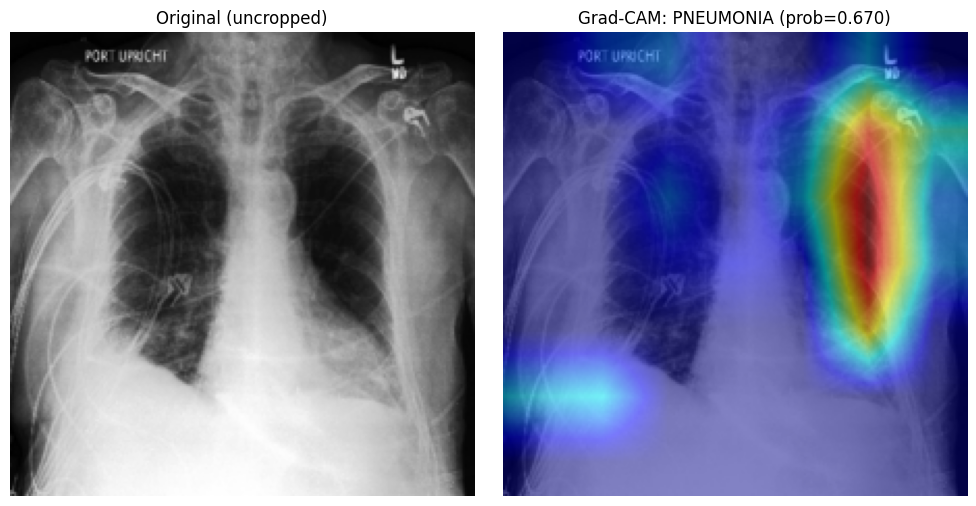

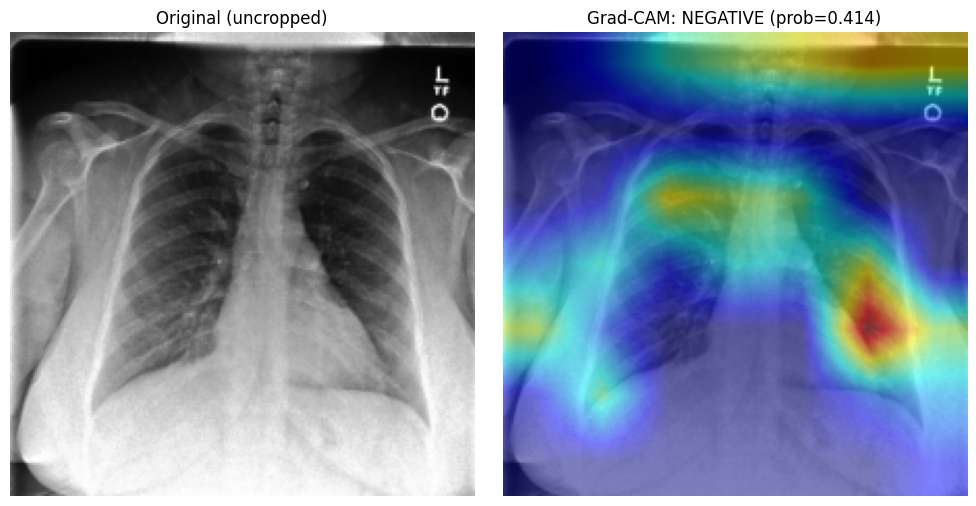

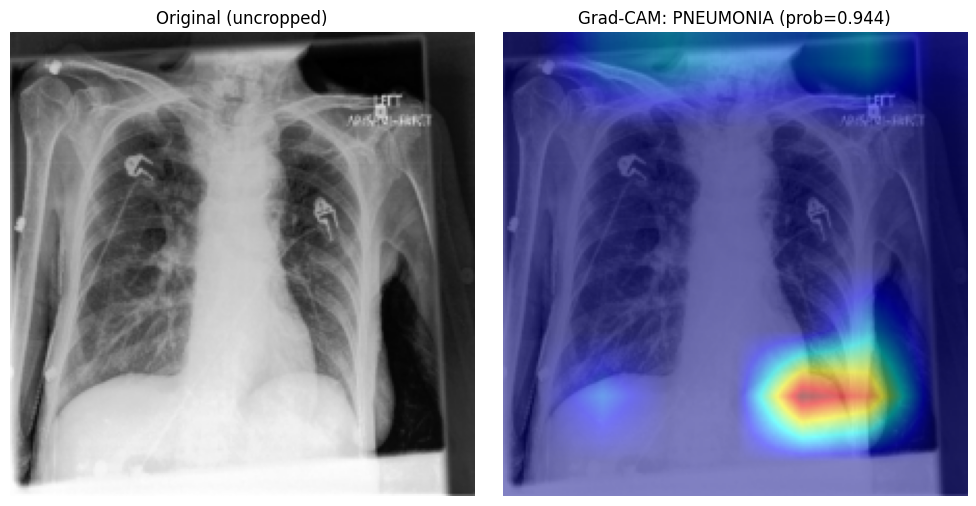

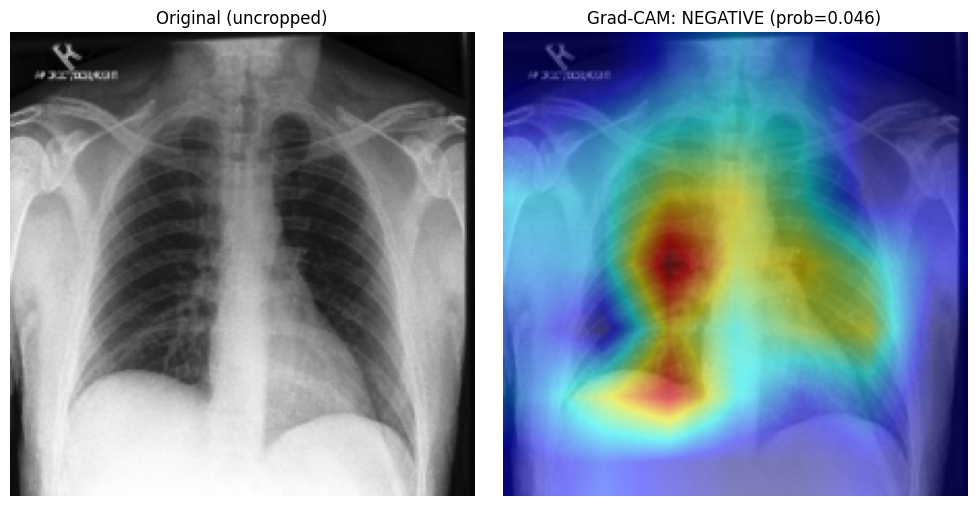

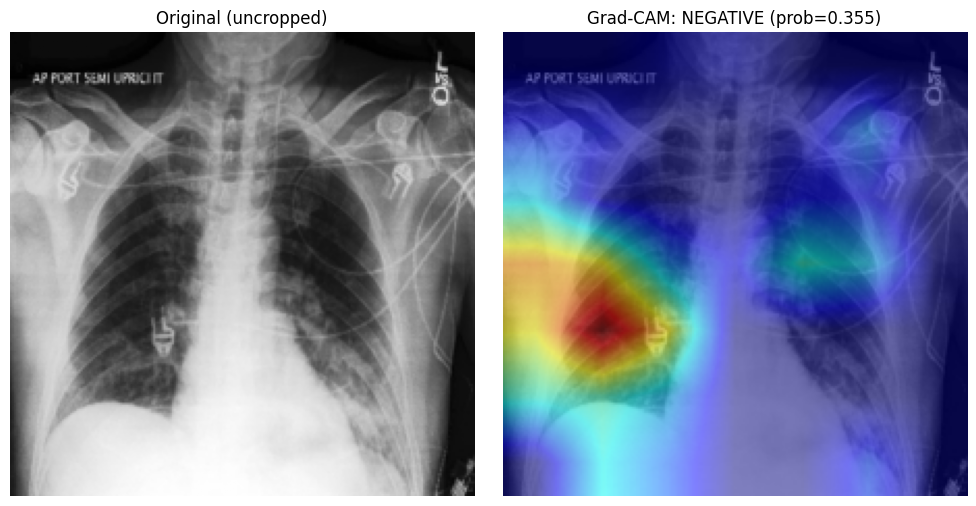

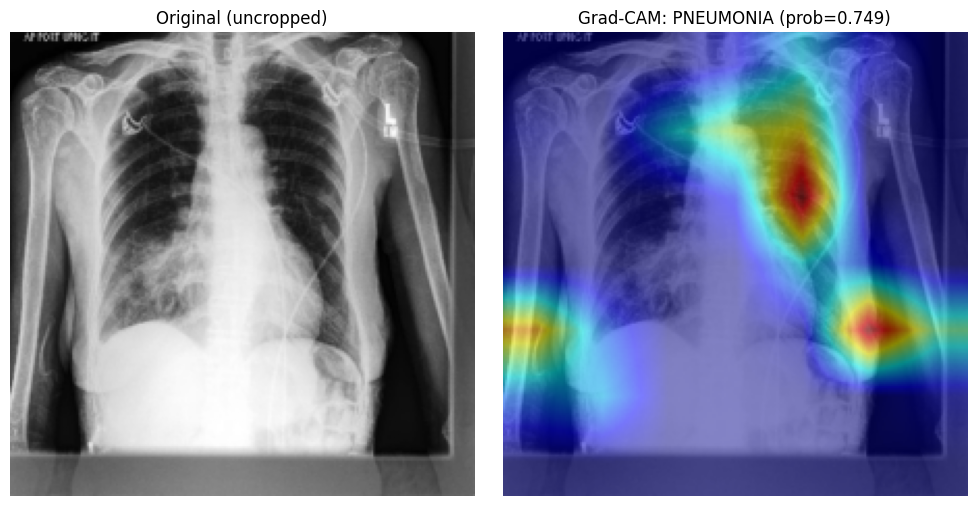

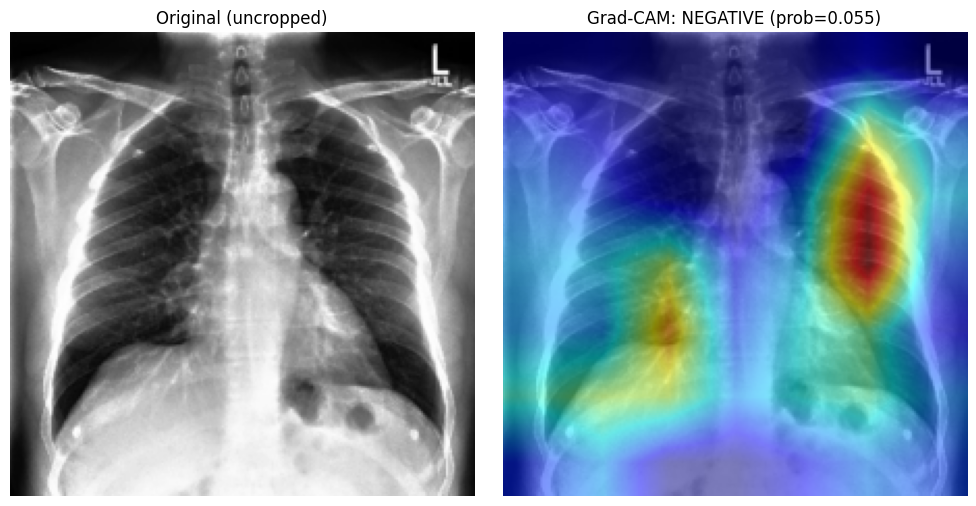

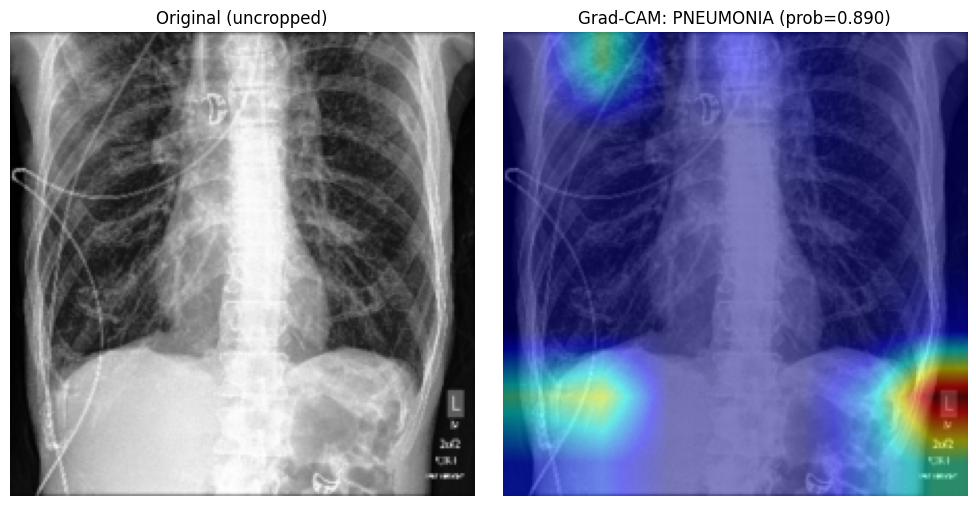

In [21]:
!pip install -q grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

def generate_gradcam_chexpert(filepath, model, cam):
    input_array = preprocess(filepath, train=False, apply_crop=False)
    input_tensor = torch.from_numpy(input_array).to(device)
    input_tensor.requires_grad_(True)

    targets = [BinaryClassifierOutputTarget(0)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    heatmap = grayscale_cam[0]

    logit = model(input_tensor)
    prob = torch.sigmoid(logit).item()
    pred_label = "PNEUMONIA" if prob > 0.5 else "NEGATIVE"

    return heatmap, prob, pred_label


def visualize_gradcam_chexpert(filepath, model, cam):
    img = load_and_convert(filepath)
    img = resize(img)  # no crop_thorax — testing uncropped
    rgb_img = np.asarray(img, dtype=np.float32) / 255.0

    heatmap, prob, pred_label = generate_gradcam_chexpert(filepath, model, cam)
    overlay = show_cam_on_image(rgb_img, heatmap, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(rgb_img)
    axes[0].set_title("Original (uncropped)")
    axes[0].axis('off')
    axes[1].imshow(overlay)
    axes[1].set_title(f"Grad-CAM: {pred_label} (prob={prob:.3f})")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    return heatmap, prob, pred_label


# Sample a mix of both classes from the test set
import random
random.seed(42)
positive_test = [p for p, l in split_data['test'] if l == 1]
negative_test = [p for p, l in split_data['test'] if l == 0]

sample_chexpert = random.sample(negative_test, 4) + random.sample(positive_test, 4)

for path in sample_chexpert:
    visualize_gradcam_chexpert(path, model, cam)